In [1]:
import os
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

print("All libraries imported successfully!")

All libraries imported successfully!


In [2]:
from pathlib import Path

# Project root
PROJECT_ROOT = Path("..")

# Dataset folder
DATASET_PATH = PROJECT_ROOT / "datasets" / "COVID-19_Radiography_Dataset"

print(DATASET_PATH)
print(DATASET_PATH.exists())

../datasets/COVID-19_Radiography_Dataset
True


In [3]:
CLASSES = [
    "COVID",
    "Normal",
    "Lung_Opacity",
    "Viral Pneumonia"
]

print(CLASSES)

['COVID', 'Normal', 'Lung_Opacity', 'Viral Pneumonia']


In [4]:
image_counts = {}

for cls in CLASSES:
    image_folder = DATASET_PATH / cls / "images"

    count = len(list(image_folder.glob("*.png")))

    image_counts[cls] = count

image_counts

{'COVID': 3616, 'Normal': 10192, 'Lung_Opacity': 6012, 'Viral Pneumonia': 1345}

In [5]:
df_counts = pd.DataFrame(
    image_counts.items(),
    columns=["Class", "Images"]
)

df_counts

,Class,Images
0,COVID,3616
1,Normal,10192
2,Lung_Opacity,6012
3,Viral Pneumonia,1345


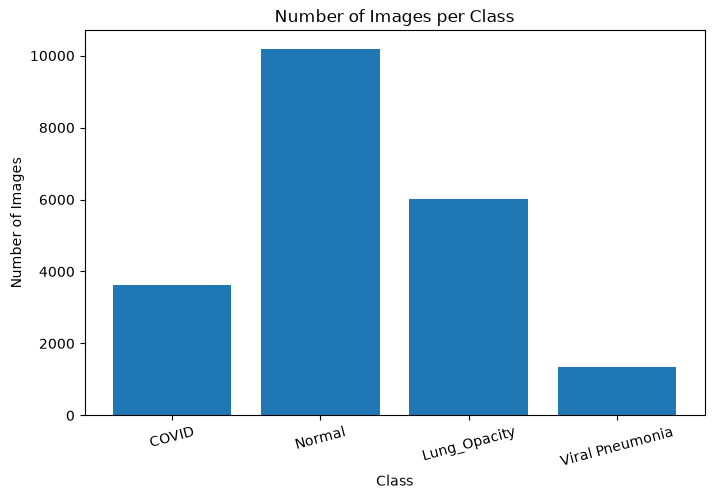

In [12]:
plt.figure(figsize=(8,5))

plt.bar(df_counts["Class"], df_counts["Images"])

plt.title("Number of Images per Class")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=15)

plt.savefig(
    PROJECT_ROOT / "figures" / "class_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

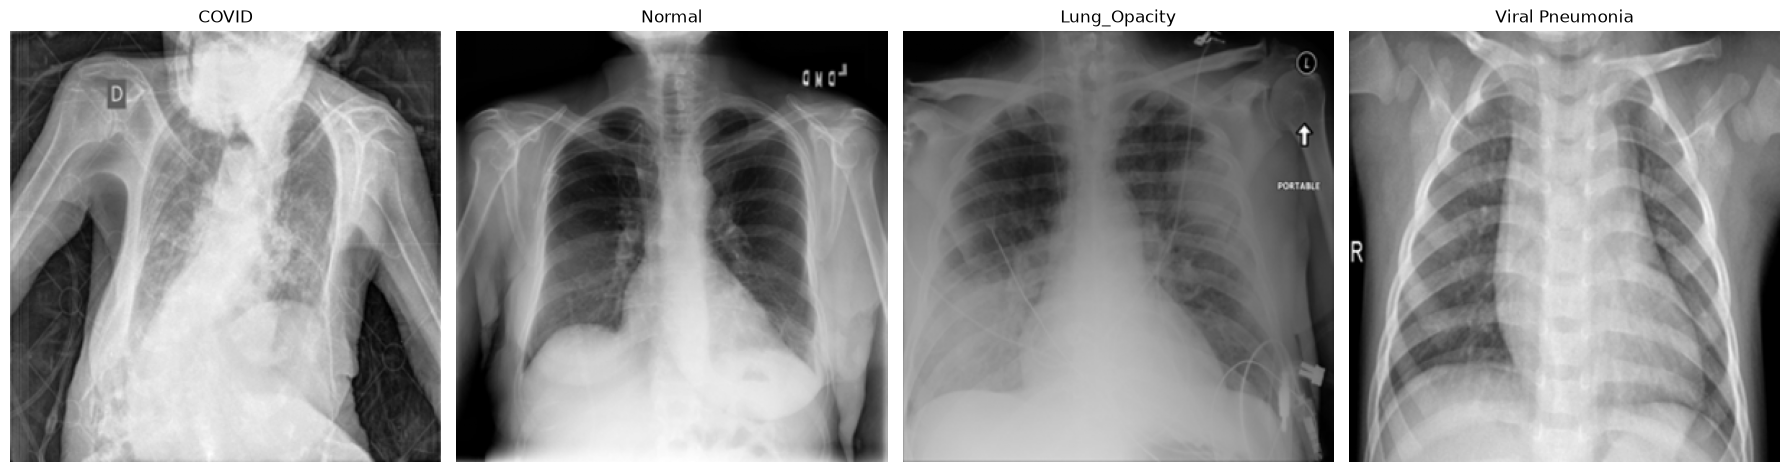

In [7]:
fig, axes = plt.subplots(1, 4, figsize=(18,5))

for i, cls in enumerate(CLASSES):

    image_folder = DATASET_PATH / cls / "images"

    image_path = random.choice(list(image_folder.glob("*.png")))

    image = Image.open(image_path)

    axes[i].imshow(image, cmap="gray")
    axes[i].set_title(cls)
    axes[i].axis("off")

plt.tight_layout()
plt.show()

In [8]:
image_sizes = []

for cls in CLASSES:

    image_folder = DATASET_PATH / cls / "images"

    for img_path in image_folder.glob("*.png"):

        img = Image.open(img_path)

        image_sizes.append(img.size)

sizes_df = pd.DataFrame(
    image_sizes,
    columns=["Width", "Height"]
)

sizes_df.describe()

,Width,Height
count,21165.0,21165.0
mean,299.0,299.0
std,0.0,0.0
min,299.0,299.0
25%,299.0,299.0
50%,299.0,299.0
75%,299.0,299.0
max,299.0,299.0


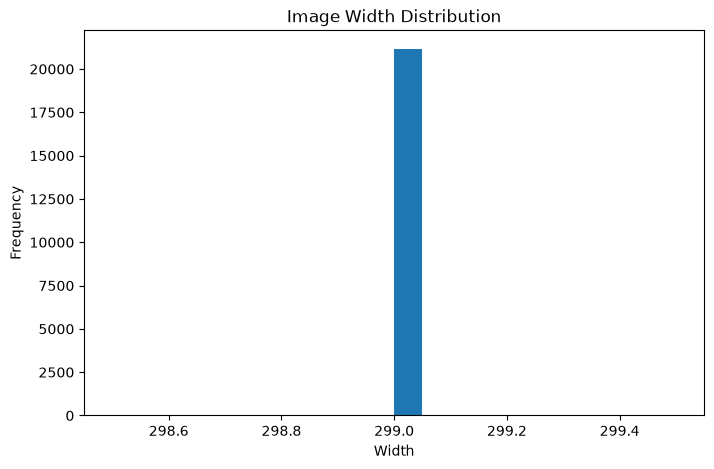

In [ ]:
plt.figure(figsize=(8,5))

plt.hist(
    sizes_df["Width"],
    bins=20
)

plt.title("Image Width Distribution")
plt.xlabel("Width")
plt.ylabel("Frequency")

plt.xticks(rotation=15)

plt.savefig(
    PROJECT_ROOT / "figures" / "class_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [10]:
corrupted = []

for cls in CLASSES:

    image_folder = DATASET_PATH / cls / "images"

    for img_path in image_folder.glob("*.png"):

        try:
            Image.open(img_path).verify()

        except Exception:

            corrupted.append(img_path)

print("Corrupted Images:", len(corrupted))

Corrupted Images: 0


In [11]:
mask_summary = {}

for cls in CLASSES:

    mask_folder = DATASET_PATH / cls / "masks"

    masks = list(mask_folder.glob("*.png"))

    mask_summary[cls] = len(masks)

pd.DataFrame(
    mask_summary.items(),
    columns=["Class", "Masks"]
)

,Class,Masks
0,COVID,3616
1,Normal,10192
2,Lung_Opacity,6012
3,Viral Pneumonia,1345
